In [1]:
!unzip '/content/drive/MyDrive/Blur study data.zip'
!unzip '/content/drive/MyDrive/Blur study data2.zip'

Archive:  /content/drive/MyDrive/Blur study data.zip
   creating: Blur study data/
  inflating: Blur study data/all_participants_combined.csv  
   creating: Blur study data/Participant_1/
  inflating: Blur study data/Participant_1/baseline_ECG_data_participant1.csv  
  inflating: Blur study data/Participant_1/baseline_GSR_data_participant1.csv  
  inflating: Blur study data/Participant_1/feedback_part.csv  
  inflating: Blur study data/Participant_1/Filtered_ECG_512Hz.csv  
  inflating: Blur study data/Participant_1/Filtered_GSR_PPG.csv  
  inflating: Blur study data/Participant_1/labeled_ECG_data_participant1.csv  
  inflating: Blur study data/Participant_1/labeled_eye_data_participant1.csv  
  inflating: Blur study data/Participant_1/labeled_GSR_data_participant1.csv  
  inflating: Blur study data/Participant_1/labeled_head_data_participant1.csv  
  inflating: Blur study data/Participant_1/merged_labeled_data_participant1.csv  
  inflating: Blur study data/Participant_1/merged_resamp

In [2]:
from scipy.signal import resample
import pandas as pd
import os
from datetime import timedelta

def resample_ecg_data(df, original_rate, target_rate=250):
    if 'Timestamp' not in df.columns:
        raise ValueError("Timestamp column is required to regenerate timestamps.")

    start_time = pd.to_datetime(df['Timestamp'].iloc[0])

    # Mode-preserved columns
    preserve_cols = {}
    for col in ['FMS', 'Condition']:
        if col in df.columns:
            preserve_cols[col] = df[col].mode().iloc[0]

    # Select numeric signal columns only (excluding mode-preserved columns if numeric)
    signal_df = df.select_dtypes(include='number').copy()
    for col in preserve_cols:
        if col in signal_df.columns:
            signal_df.drop(columns=col, inplace=True)

    # Resample signal
    num_original_samples = len(signal_df)
    num_target_samples = int(num_original_samples * target_rate / original_rate)
    resampled_array = resample(signal_df.values, num_target_samples, axis=0)
    resampled_df = pd.DataFrame(resampled_array, columns=signal_df.columns)

    # Add preserved columns with constant mode value
    for col, mode_val in preserve_cols.items():
        resampled_df[col] = mode_val

    # Reconstruct timestamps
    interval = 1 / target_rate
    resampled_timestamps = [start_time + timedelta(seconds=i * interval) for i in range(num_target_samples)]
    resampled_df['Timestamp'] = resampled_timestamps

    return resampled_df



def load_participant_data(base_path, participant_ids, subfolder_prefix, filename_prefix, resample_ecg=False, original_rate=None):
    all_data = []

    for pid in participant_ids:
        file_path = os.path.join(base_path, f"{subfolder_prefix}{pid}", f"{filename_prefix}{pid}.csv")

        try:
            df = pd.read_csv(file_path)

            print(f"[Participant {pid}] Missing values:\n", df.isna().sum())
            df.dropna(inplace=True)

            if resample_ecg:
                if original_rate is None:
                    raise ValueError("Original sampling rate must be provided for ECG resampling.")
                df = resample_ecg_data(df, original_rate)
            df['participant'] = pid
            all_data.append(df)

        except FileNotFoundError:
            print(f"File not found for participant {pid}: {file_path}")
        except pd.errors.EmptyDataError:
            print(f"Empty or invalid file for participant {pid}: {file_path}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

base_path = r'/content/Blur study data'

participant_ids_train = range(1, 16)
# participant_ids_test = range(13, 15)

# ECG
original_ecg_rate = 500
train_ecg_data1 = load_participant_data(
    base_path,
    participant_ids_train,
    "Participant_",
    "labeled_ECG_data_participant",
    resample_ecg=True,
    original_rate=original_ecg_rate
)
# Eye Tracking
train_eye_data1 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_eye_data_participant")
# test_eye_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_eye_participant")

# Head Tracking
train_head_data1 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_head_data_participant")
# test_head_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_head_data_participant")

# GSR (Galvanic Skin Response)
train_gsr_data1 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_GSR_data_participant")
# test_gsr_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_GSR_data_participant")



/tmp/ipython-input-126074403.py:50: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 1] Missing values:
 Timestamp                           0
ECG_test1_ECGtoHR_LA_RA_CAL         0
Lead I (LA-RA)                      0
Lead II (LL-LA)                     0
Lead III (LL-RA)                    0
Vx-RL                               0
FMS                            612197
Condition                      612197
dtype: int64


/tmp/ipython-input-126074403.py:50: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 2] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 639427
Condition           623555
dtype: int64


/tmp/ipython-input-126074403.py:50: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


...

[Participant 11] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 531434
Condition           531434
dtype: int64


/tmp/ipython-input-126074403.py:50: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 12] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 333389
Condition           333389
dtype: int64


/tmp/ipython-input-126074403.py:50: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 13] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 389276
Condition           389276
dtype: int64
[Participant 14] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 263714
Condition           263714
dtype: int64
[Participant 15] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 245756
Condition           245756
dtype: int64
[Participant 1] Missing values:
 timestamp                               0
LeftEye_Openness_Openness               0
RightEye_Openness_Openness              0
LeftEye_PupilDilation_PupilDilation     0
RightEye_PupilDilation_PupilDilation    0
LeftEye_PupilPosition_X                 0
LeftEye

In [3]:
def load_participant_data(
    base_path, participant_ids, subfolder_prefix, filename_prefix,
    resample_ecg=False, original_rate=None, auto_detect_sampling=False
):
    all_data = []

    for pid in participant_ids:
        file_path = os.path.join(base_path, f"{subfolder_prefix}{pid}", f"{filename_prefix}{pid}.csv")

        try:
            df = pd.read_csv(file_path)

            print(f"[Participant {pid}] Missing values:\n", df.isna().sum())
            df.dropna(inplace=True)
            if df.empty:
                print(f"Empty DataFrame for participant {pid}: {file_path}")
                continue

            if resample_ecg:
                # Only resample if auto_detect_sampling is enabled and actual rate is different
                if auto_detect_sampling:
                    timestamps = pd.to_datetime(df["Timestamp"])
                    # Compute actual rate (based on median interval)
                    actual_interval = (timestamps.diff().dt.total_seconds().median())
                    actual_rate = round(1 / actual_interval) if actual_interval else None
                    print(f"[Participant {pid}] Detected ECG rate: {actual_rate} Hz")

                    if actual_rate and actual_rate != 250:
                        df = resample_ecg_data(df, actual_rate)
                else:
                    if original_rate is None:
                        raise ValueError("Original sampling rate must be provided for ECG resampling.")
                    df = resample_ecg_data(df, original_rate)

            df['participant'] = pid
            all_data.append(df)

        except FileNotFoundError:
            print(f"File not found for participant {pid}: {file_path}")
        except pd.errors.EmptyDataError:
            print(f"Empty or invalid file for participant {pid}: {file_path}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()
def resample_ecg_data(df, original_rate, target_rate=250):
    if 'Timestamp' not in df.columns:
        raise ValueError("Timestamp column is required to regenerate timestamps.")

    start_time = pd.to_datetime(df['Timestamp'].iloc[0])

    # Mode-preserved columns
    preserve_cols = {}
    for col in ['FMS', 'Condition']:
        if col in df.columns:
            preserve_cols[col] = df[col].mode().iloc[0]

    # Select numeric signal columns only (excluding mode-preserved columns if numeric)
    signal_df = df.select_dtypes(include='number').copy()
    for col in preserve_cols:
        if col in signal_df.columns:
            signal_df.drop(columns=col, inplace=True)

    # Resample signal
    num_original_samples = len(signal_df)
    num_target_samples = int(num_original_samples * target_rate / original_rate)
    resampled_array = resample(signal_df.values, num_target_samples, axis=0)
    resampled_df = pd.DataFrame(resampled_array, columns=signal_df.columns)

    # Add preserved columns with constant mode value
    for col, mode_val in preserve_cols.items():
        resampled_df[col] = mode_val

    # Reconstruct timestamps
    interval = 1 / target_rate
    resampled_timestamps = [start_time + timedelta(seconds=i * interval) for i in range(num_target_samples)]
    resampled_df['Timestamp'] = resampled_timestamps

    return resampled_df
participant_ids_dataset3 = range(1, 16)
base_path='/content/drive/MyDrive/CyberSense/User Study/User Study Data/Processed data'
# ECG: Let the loader detect which files to resample
train_ecg_data3 = load_participant_data(
    base_path,
    participant_ids_dataset3,
    "Participant_",
    "labeled_ECG_data_participant",
    resample_ecg=True,
    auto_detect_sampling=True  # Automatically detects sampling rate
)

# Other signals (already 250 Hz)
#train_eye_data3 = load_participant_data(base_path, participant_ids_dataset3, "Participant_", "labeled_eye_data_participant")
train_head_data3 = load_participant_data(base_path, participant_ids_dataset3, "Participant_", "labeled_head_data_participant")
train_gsr_data3 = load_participant_data(base_path, participant_ids_dataset3, "Participant_", "labeled_GSR_data_participant")
train_ecg_data3

[Participant 1] Missing values:
 Timestamp               0
Lead I (LA-RA)          0
Lead II (LL-LA)         0
Lead III (LL-RA)        0
Vx-RL                   0
FMS                 33772
Condition            2740
dtype: int64
[Participant 1] Detected ECG rate: 500 Hz


/tmp/ipython-input-226835109.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 2] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 309530
Condition           309530
dtype: int64
[Participant 2] Detected ECG rate: 250 Hz


/tmp/ipython-input-226835109.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 3] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 306289
Condition           306289
dtype: int64
[Participant 3] Detected ECG rate: 250 Hz
[Participant 4] Missing values:
 Timestamp              0
Lead I (LA-RA)         0
Lead II (LL-LA)        0
Lead III (LL-RA)       0
Vx-RL                  0
FMS                 8411
Condition           8411
dtype: int64
[Participant 4] Detected ECG rate: 250 Hz
[Participant 5] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 213455
Condition           213455
dtype: int64
[Participant 5] Detected ECG rate: 250 Hz
[Participant 6] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS            

/tmp/ipython-input-226835109.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 9] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 305490
Condition           305490
dtype: int64
[Participant 9] Detected ECG rate: 250 Hz
[Participant 10] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 417179
Condition           417179
dtype: int64
[Participant 10] Detected ECG rate: 250 Hz
[Participant 11] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 231889
Condition           231889
dtype: int64
[Participant 11] Detected ECG rate: 250 Hz
[Participant 12] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                  

/tmp/ipython-input-226835109.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 15] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 244027
Condition           236094
dtype: int64
[Participant 15] Detected ECG rate: 250 Hz
[Participant 1] Missing values:
 Time              0
#Frame            0
HeadQRotationX    0
HeadQRotationY    0
HeadQRotationZ    0
HeadQRotationW    0
HeadEulX          0
HeadEulY          0
HeadEulZ          0
FMS               0
Condition         0
dtype: int64
[Participant 2] Missing values:
 Time              0
#Frame            0
HeadQRotationX    0
HeadQRotationY    0
HeadQRotationZ    0
HeadQRotationW    0
HeadEulX          0
HeadEulY          0
HeadEulZ          0
FMS               0
Condition         0
dtype: int64
[Participant 3] Missing values:
 Time              0
#Frame            0
HeadQRotationX    0
HeadQRotationY    0
HeadQRotationZ    0
HeadQRotationW    0
HeadEulX          0
HeadEulY        

,Lead I (LA-RA),Lead II (LL-LA),Lead III (LL-RA),Vx-RL,FMS,Condition,Timestamp,participant
0,0.083909,-0.075311,0.008598,-0.055048,8.0,NB,2025-05-06 16:32:46.810000,1
1,0.146116,-0.067326,0.078791,-0.087042,8.0,NB,2025-05-06 16:32:46.814000,1
2,0.136238,-0.062681,0.073557,-0.065467,8.0,NB,2025-05-06 16:32:46.818000,1
3,0.140020,-0.052573,0.087448,-0.070618,8.0,NB,2025-05-06 16:32:46.822000,1
4,0.084118,-0.045535,0.038583,-0.060620,8.0,NB,2025-05-06 16:32:46.826000,1
...,...,...,...,...,...,...,...,...
1457484,-0.072107,0.127933,0.055826,-0.174796,5.0,NB,2025-06-25 18:37:49.091,15
1457485,-0.079731,0.134851,0.055121,-0.168986,5.0,NB,2025-06-25 18:37:49.095,15
1457486,-0.091567,0.145087,0.053520,-0.160686,5.0,NB,2025-06-25 18:37:49.099,15
1457487,-0.098998,0.156676,0.057677,-0.150513,5.0,NB,2025-06-25 18:37:49.103,15


In [4]:
import numpy as np
id_offset = train_ecg_data1['participant'].max()

# train_eye_data3['participant'] += id_offset
train_head_data3['participant'] += id_offset
train_gsr_data3['participant'] += id_offset
train_ecg_data3['participant'] += id_offset
print(np.unique(train_ecg_data1['participant']),np.unique(train_ecg_data3['participant']))


all_data_gsr = pd.concat([train_gsr_data1, train_gsr_data3], ignore_index=True)
all_data_ecg = pd.concat([train_ecg_data1, train_ecg_data3], ignore_index=True)

all_data_gsr['FMS'] = (
    all_data_gsr['FMS']
    .astype(str)
    .str.replace('*', '', regex=False)  # remove asterisk
    .str.strip()
)
all_data_ecg['FMS']=(all_data_ecg['FMS']
    .astype(str)
    .str.replace('*', '', regex=False)  # remove asterisk
    .str.strip()
)
all_data_ecg['FMS']=pd.to_numeric(all_data_ecg['FMS'], errors='coerce')

all_data_gsr['FMS'] = pd.to_numeric(all_data_gsr['FMS'], errors='coerce')
all_data_gsr

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] [16 17 18 19 20 21 24 25 26 27 28 29 30]


,Timestamp,GSR_Filtered,PPG_Filtered,FMS,Condition,participant
0,2025-04-04 16:56:03.759,0.001744,123.558662,4.0,NB,1
1,2025-04-04 16:56:03.778,0.003374,191.259492,4.0,NB,1
2,2025-04-04 16:56:03.798,0.004946,241.255469,4.0,NB,1
3,2025-04-04 16:56:03.817,0.006283,261.810151,4.0,NB,1
4,2025-04-04 16:56:03.837,0.007244,245.547978,4.0,NB,1
...,...,...,...,...,...,...
1769336,2025-06-25 18:37:49.074,-0.000104,-1.919787,5.0,NB,30
1769337,2025-06-25 18:37:49.081,-0.000182,-3.024155,5.0,NB,30
1769338,2025-06-25 18:37:49.089,-0.000261,-4.156642,5.0,NB,30
1769339,2025-06-25 18:37:49.097,-0.000341,-5.299112,5.0,NB,30


Descriptive stat

/tmp/ipython-input-163039164.py:15: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  .resample("1S")  # 1 Hz = 1 sample per second


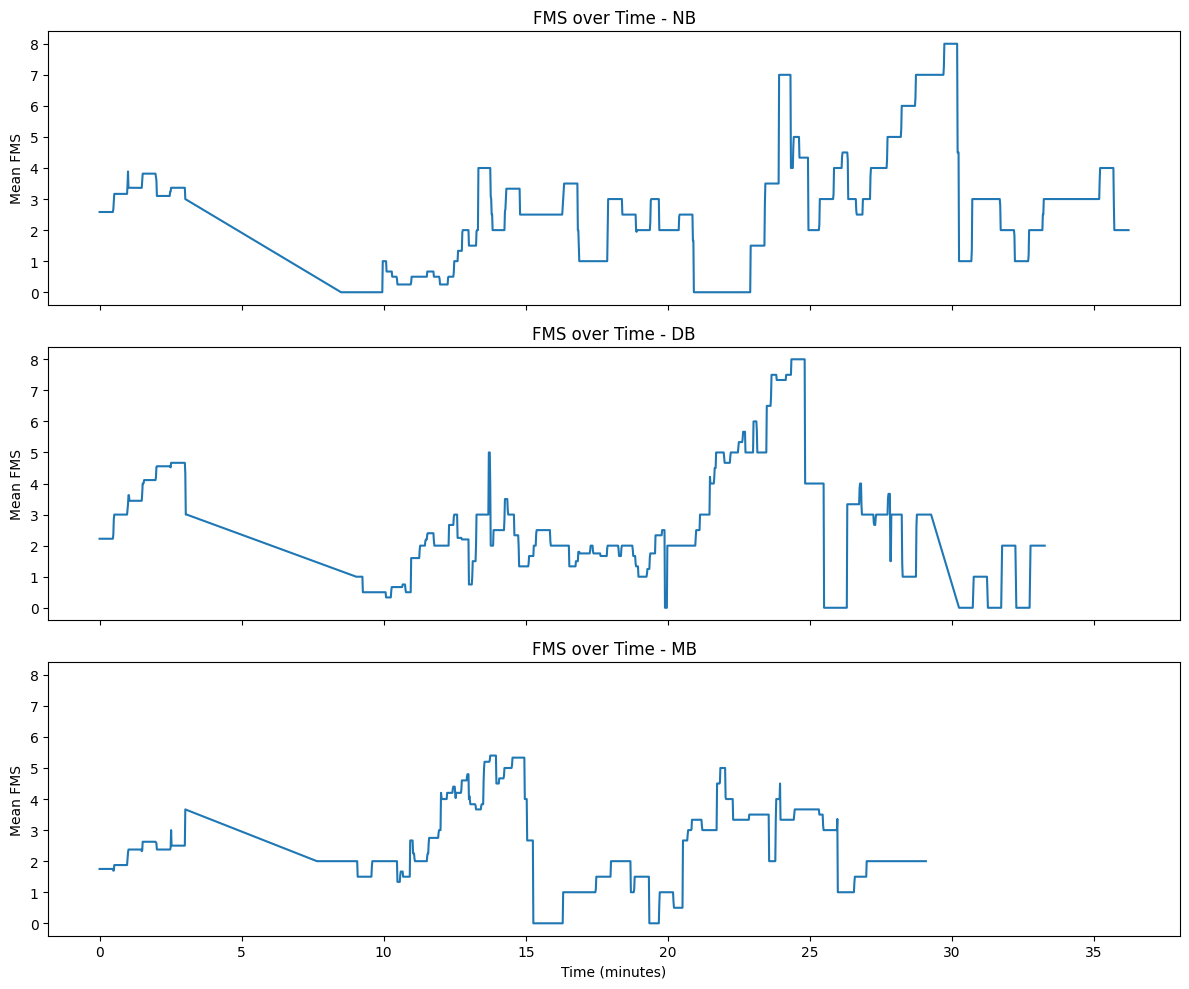

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Step 1: Convert timestamp to datetime ----
all_data_gsr["Timestamp"] = pd.to_datetime(all_data_gsr["Timestamp"])

# ---- Step 2: Set timestamp as index for resampling ----
all_data_gsr = all_data_gsr.set_index("Timestamp")

# ---- Step 3: Resample to 1 Hz (per participant × condition) ----
resampled = (
    all_data_gsr
    .groupby(["participant", "Condition"])
    .resample("1S")  # 1 Hz = 1 sample per second
    .mean()
    .reset_index()
)

# ---- Step 4: Normalize time in seconds from start for each participant ----
resampled["Time_sec"] = resampled.groupby("participant")["Timestamp"].transform(
    lambda x: (x - x.min()).dt.total_seconds()
)

# ---- Step 5: Compute participant mean FMS per second ----
fms_time = (
    resampled
    .groupby(["Condition", "participant", "Time_sec"])["FMS"].mean()
    .reset_index()
)

# ---- Step 6: Average across participants ----
fms_condition_time = (
    fms_time
    .groupby(["Condition", "Time_sec"])["FMS"].mean()
    .reset_index()
)

# ---- Step 7: Convert seconds → minutes ----
fms_condition_time["Time_min"] = fms_condition_time["Time_sec"] / 60.0

# ---- Step 8: Plot in subplots ----
conditions = ["NB", "DB", "MB"]
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)

for ax, cond in zip(axes, conditions):
    subset = fms_condition_time[fms_condition_time["Condition"] == cond]
    sns.lineplot(data=subset, x="Time_min", y="FMS", ax=ax, color="C0")
    ax.set_title(f"FMS over Time - {cond}")
    ax.set_ylabel("Mean FMS")
    ax.set_xlabel("Time (minutes)")

plt.tight_layout()
plt.show()


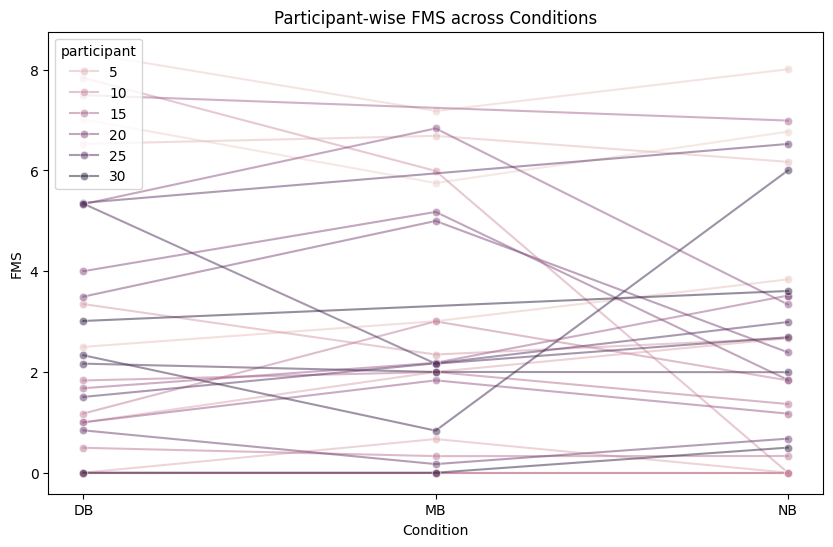

In [22]:
fms_participant = resampled.groupby(["participant", "Condition"])["FMS"].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data=fms_participant, x="Condition", y="FMS", hue="participant", marker="o", alpha=0.5)
plt.title("Participant-wise FMS across Conditions")
plt.show()


/tmp/ipython-input-107832526.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=resampled, x="Condition", y="FMS", palette="Set2")


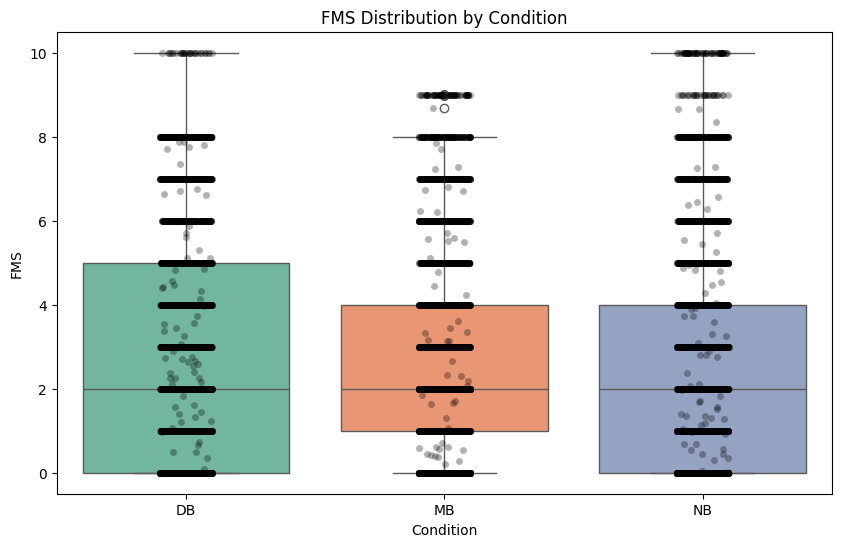

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(data=resampled, x="Condition", y="FMS", palette="Set2")
sns.stripplot(data=resampled, x="Condition", y="FMS", color="black", alpha=0.3)
plt.title("FMS Distribution by Condition")
plt.show()


In [21]:
import pandas as pd

# ---- Compute mean & std for FMS and GSR per condition ----
summary_stats = (
    resampled
    .groupby("Condition")[["FMS", "GSR_Filtered"]]
    .agg(["mean", "std"])
    .reset_index()
)

# Flatten MultiIndex columns
summary_stats.columns = ["Condition", "FMS_mean", "FMS_std", "GSR_mean", "GSR_std"]

print(summary_stats)


  Condition  FMS_mean   FMS_std  GSR_mean   GSR_std
0        DB  2.837975  2.697170  0.000010  0.004806
1        MB  2.655797  2.464210  0.000002  0.004003
2        NB  2.607761  2.460316 -0.000011  0.004006


In [33]:
summary_stats=all_data_ecg.groupby('Condition')['Lead II (LL-LA)'].describe()
summary_stats

,count,mean,std,min,25%,50%,75%,max
Condition,,,,,,,,
DB,1659701.0,2.948515e-06,0.218193,-2.316631,-0.067693,-0.026518,0.013961,4.664424
MB,918938.0,-5.168630e-07,0.288536,-19.912292,-0.056395,-0.024225,0.011960,133.588671
NB,886899.0,4.934417e-06,0.212514,-1.877728,-0.060865,-0.022947,0.027816,4.284654


In [30]:
import pandas as pd

# List of subscales
metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]

# ---------- Compute summary stats ----------
summary_list = []

for cond in merged["Condition"].unique():
    subset = merged[merged["Condition"] == cond]

    row = {"Condition": cond}

    for metric in metrics:
        row[f"{metric}_pre_mean"] = subset[f"{metric}_pre"].mean()
        row[f"{metric}_pre_std"]  = subset[f"{metric}_pre"].std()
        row[f"{metric}_post_mean"] = subset[f"{metric}_post"].mean()
        row[f"{metric}_post_std"]  = subset[f"{metric}_post"].std()

    summary_list.append(row)

# Convert to DataFrame
summary_table = pd.DataFrame(summary_list)

summary_table


,Condition,Nausea_pre_mean,Nausea_pre_std,Nausea_post_mean,Nausea_post_std,Oculomotor_pre_mean,Oculomotor_pre_std,Oculomotor_post_mean,Oculomotor_post_std,Disorientation_pre_mean,Disorientation_pre_std,Disorientation_post_mean,Disorientation_post_std,Total_pre_mean,Total_pre_std,Total_post_mean,Total_post_std
0,NB,9.812571,17.994937,21.533143,29.389946,12.344571,16.452135,23.606286,21.656824,11.136000,23.341498,26.646857,32.797069,12.929714,19.440867,27.248571,28.678343
1,DB,5.021053,8.798757,20.335263,27.360784,9.175789,9.993719,26.330526,23.094846,6.227368,10.585024,28.206316,32.117555,8.168947,9.832072,28.542105,27.351195
2,MB,7.227273,13.707071,17.345455,24.140930,9.417576,15.514751,24.577576,26.935031,10.967273,20.516533,27.418182,38.982967,10.426667,17.709739,26.293333,32.260682


In [40]:
import pandas as pd
from scipy.stats import wilcoxon

# ---------- Load Data ----------
pre_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores.csv")
post_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores.csv")
pre_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores_ksu.csv")
post_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores_ksu.csv")

# Merge pre and post
pre_ssq = pd.concat([pre_df1, pre_df2], axis=0)
post_ssq = pd.concat([post_df1, post_df2], axis=0)

# Merge on Participant + Session + Condition
merged = pd.merge(
    pre_ssq,
    post_ssq,
    on=["Participant", "Session", "Condition"],
    suffixes=("_pre", "_post")
)

# ---------- Wilcoxon signed-rank test (Pre vs Post) ----------
metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]

print("====== Wilcoxon Signed-Rank Test: Pre vs Post ======")
for metric in metrics:
    pre_vals = merged[f"{metric}_pre"]
    post_vals = merged[f"{metric}_post"]

    try:
        stat, p_val = wilcoxon(post_vals, pre_vals)
        print(f"{metric}: W={stat:.3f}, p={p_val:.4f}")
    except ValueError as e:
        print(f"{metric}: Could not compute Wilcoxon test - {e}")


====== Wilcoxon Signed-Rank Test: Pre vs Post ======
Nausea: W=62.000, p=0.0000
Oculomotor: W=91.500, p=0.0000
Disorientation: W=40.500, p=0.0000
Total: W=66.500, p=0.0000


In [38]:
import pandas as pd
from scipy.stats import friedmanchisquare

# ---------- Load Data ----------
pre_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores.csv")
post_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores.csv")
pre_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores_ksu.csv")
post_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores_ksu.csv")

# Merge pre and post
pre_ssq = pd.concat([pre_df1, pre_df2], axis=0)
post_ssq = pd.concat([post_df1, post_df2], axis=0)

# Merge on Participant + Session + Condition
merged = pd.merge(
    pre_ssq,
    post_ssq,
    on=["Participant", "Session", "Condition"],
    suffixes=("_pre", "_post")
)

# ---------- Friedman Test (within-subject across conditions) ----------
metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]

print("====== Friedman Test: Across Conditions (Post only) ======")
for metric in metrics:
    # Pivot: rows = participants, cols = conditions, values = post scores
    pivot = merged.pivot_table(
        index="Participant",
        columns="Condition",
        values=f"{metric}_post"
    ).dropna()  # drop if missing

    if pivot.shape[1] >= 3:  # Friedman requires >= 3 related groups
        stat, p_val = friedmanchisquare(*[pivot[c] for c in pivot.columns])
        print(f"{metric}: χ²={stat:.3f}, p={p_val:.4f}")
    else:
        print(f"{metric}: Not enough conditions for Friedman test")


====== Friedman Test: Across Conditions (Post only) ======
Nausea: χ²=1.485, p=0.4760
Oculomotor: χ²=0.692, p=0.7074
Disorientation: χ²=2.419, p=0.2983
Total: χ²=0.432, p=0.8058


In [28]:
import pandas as pd
from scipy.stats import wilcoxon
from itertools import combinations

# ---------- Load Data ----------
pre_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores.csv")
post_df2 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores.csv")
pre_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/pre_ssq_scores_ksu.csv")
post_df1 = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/condition3/post_ssq_scores_ksu.csv")

# Merge pre and post
pre_ssq = pd.concat([pre_df1, pre_df2], axis=0)
post_ssq = pd.concat([post_df1, post_df2], axis=0)

# Merge on Participant + Session + Condition
merged = pd.merge(
    pre_ssq,
    post_ssq,
    on=["Participant", "Session", "Condition"],
    suffixes=("_pre", "_post")
)

# ---------- Compute change scores ----------
metrics = ["Nausea", "Oculomotor", "Disorientation", "Total"]
for metric in metrics:
    merged[f"{metric}_change"] = merged[f"{metric}_post"] - merged[f"{metric}_pre"]

# ---------- Aggregate to participant-level (mean change per condition) ----------
agg = merged.groupby(["Participant", "Condition"])[[f"{m}_change" for m in metrics]].mean().reset_index()

# ---------- Wilcoxon signed-rank tests between conditions ----------
conditions = ["NB", "DB", "MB"]
pairs = list(combinations(conditions, 2))

print("====== Wilcoxon Tests on Change Scores (Between Conditions) ======")
for metric in metrics:
    print(f"\n--- {metric}_change ---")
    for cond1, cond2 in pairs:
        # Select participants who have both conditions
        subset = agg[agg["Condition"].isin([cond1, cond2])]
        wide = subset.pivot(index="Participant", columns="Condition", values=f"{metric}_change").dropna()

        if wide.shape[0] < 2:
            print(f"{cond1} vs {cond2}: not enough paired data")
            continue

        stat, p_val = wilcoxon(wide[cond1], wide[cond2])
        print(f"{cond1} vs {cond2}: W={stat:.3f}, p={p_val:.4f}")


====== Wilcoxon Tests on Change Scores (Between Conditions) ======

--- Nausea_change ---
NB vs DB: W=121.500, p=0.8704
NB vs MB: W=68.500, p=0.1697
DB vs MB: W=57.000, p=0.8644

--- Oculomotor_change ---
NB vs DB: W=76.500, p=0.0613
NB vs MB: W=66.000, p=0.0160
DB vs MB: W=121.500, p=0.8709

--- Disorientation_change ---
NB vs DB: W=82.000, p=0.3892
NB vs MB: W=54.500, p=0.2967
DB vs MB: W=72.000, p=0.3527

--- Total_change ---
NB vs DB: W=144.000, p=0.4235
NB vs MB: W=72.500, p=0.0463
DB vs MB: W=126.000, p=0.9870


In [14]:
import csv


data = [
    (1, "NB", "DB", "MB"),
    (2, "NB", "MB", "DB"),
    (3, "DB", "NB", "MB"),
    (4, "DB", "MB", "NB"),
    (5, "MB", "NB", "DB"),
    (6, "MB", "DB", "NB"),
    (7, "NB", "DB", "MB"),
    (8, "NB", "MB", "DB"),
    (9, "DB", "NB", "MB"),
    (10, "DB", "MB", "NB"),
    (11, "MB", "NB", "DB"),
    (12, "MB", "DB", "NB"),
    (13, "NB", "DB", "MB"),
    (14, "NB", "MB", "DB"),
    (15, "DB", "NB", "MB"),
]

# Write to CSV
with open("session_orders.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Participant", "Session 1", "Session 2", "Session 3"])
    writer.writerows(data)

print("CSV file 'session_orders.csv' created successfully.")


CSV file 'session_orders.csv' created successfully.


PRESENCE

In [27]:
import pandas as pd

df = pd.read_csv("/content/Copy of Post- Study-SSQ + IPQ  (Responses) - Form Responses 1 (3).csv")
orders = pd.read_csv("session_orders.csv")

# Map participant names to integers
participant_map = {name: i+1 for i, name in enumerate(df["Name"].unique())}
df["Participant_Num"] = df["Name"].map(participant_map)

# Map session number to condition using numeric participant IDs
def get_condition(row):
    session_value = row["Session"]
    if isinstance(session_value, str):
        session_num = int(session_value.strip()[-1])
    else:
        session_num = int(session_value)

    match = orders.loc[
        orders["Participant"] == row["Participant_Num"],
        f"Session {session_num}"
    ]

    if match.empty:
        return None
    return match.values[0]

df["Condition"] = df.apply(get_condition, axis=1)
df.head()


,Timestamp,Name,Session,"How aware were you of the real world surrounding you while navigating in the virtual world? (i.e. sounds, room temperature, other people, etc.)?",How real did the virtual world seem to you?,"I had a sense of acting in the virtual space, rather than operating something from outside.",How much did your experience in the virtual environment seem consistent with your real-world experience?,How real did the virtual world seem to you?.1,I did not feel present in the virtual space.,I was not aware of my real environment.,...,\nI thought the system was easy to use.,I think that I would need the support of a technical person to be able to use this system.,\nI found the various functions in this system were well integrated.,I thought there was too much inconsistency in this system.,I would imagine that most people would learn to use this system very quickly.,I found the system very cumbersome to use.,I felt very confident using the system.,I needed to learn a lot of things before I could get going with this system.,Participant_Num,Condition
0,4/4/2025 17:01:16,A H M Nazmus Sakib,1,1,4.0,3,4.0,4.0,2.0,1.0,...,2,1,4,1,3,5,4,1,1,NB
1,4/4/2025 17:11:44,A H M Nazmus Sakib,2,1,4.0,3,3.0,3.0,3.0,0.0,...,3,1,4,1,4,5,4,1,1,DB
2,4/4/2025 17:23:40,A H M Nazmus Sakib,3,5,4.0,4,3.0,3.0,2.0,0.0,...,4,1,4,1,4,5,4,1,1,MB
3,4/17/2025 15:37:12,Guohao Yang,1,1,1.0,5,4.0,2.0,3.0,2.0,...,3,2,3,1,2,1,2,1,2,NB
4,4/17/2025 15:48:49,Guohao Yang,2,1,4.0,3,4.0,2.0,2.0,0.0,...,3,2,2,1,2,1,3,1,2,MB


relation with presence

In [28]:
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon
import itertools


subscales = {
    "General Presence": [
        "I did not feel present in the virtual space.",
        "I was not aware of my real environment.",
        'In the computer-generated world, I had a sense of "being there"',
        "Somehow I felt that the virtual world surrounded me.",
        "I felt present in the virtual space.",
    ],
    "Spatial Presence": [
        "How aware were you of the real world surrounding you while navigating in the virtual world? (i.e. sounds, room temperature, other people, etc.)?",
        "I had a sense of acting in the virtual space, rather than operating something from outside.",
        "How much did your experience in the virtual environment seem consistent with your real-world experience?",
        "I still paid attention to the real environment.",
    ],
    "Involvement": [
        "I was completely captivated by the virtual world.",
    ],
    "Realism": [
        "How real did the virtual world seem to you?",
        "How real did the virtual world seem to you?.1",
        "The virtual world seemed more realistic than the real world.",
        "I felt like I was just perceiving pictures.",
    ]
}

# ---------- Compute Subscale Scores ----------
for sub, items in subscales.items():
    df[sub] = df[items].mean(axis=1)

# Keep relevant columns
subscale_scores = df[["Name", "Condition"] + list(subscales.keys())]

# ---------- Aggregate (fix duplicates) ----------
# average per participant per condition
agg = subscale_scores.groupby(["Name", "Condition"], as_index=False).mean()

for metric in subscales.keys():
    wide = agg.pivot(index="Name", columns="Condition", values=metric).dropna()

    if set(["NB", "DB", "MB"]).issubset(wide.columns):  # ensure all conditions exist
        print(f"\n===== {metric} =====")
        stat, p = friedmanchisquare(wide["NB"], wide["DB"], wide["MB"])
        print(f"Friedman test: chi2={stat:.3f}, p={p:.4f}")

        if p < 0.05:
            print("  Post-hoc Wilcoxon tests:")
            for cond1, cond2 in itertools.combinations(["NB", "DB", "MB"], 2):
                w_stat, w_p = wilcoxon(wide[cond1], wide[cond2])
                print(f"    {cond1} vs {cond2}: W={w_stat}, p={w_p:.4f}")



===== General Presence =====
Friedman test: chi2=4.500, p=0.1054

===== Spatial Presence =====
Friedman test: chi2=1.200, p=0.5488

===== Involvement =====
Friedman test: chi2=3.586, p=0.1664

===== Realism =====
Friedman test: chi2=0.222, p=0.8948


In [36]:
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon

# Define all presence-related items (combine all subscales or just presence-relevant items)
presence_items = [
    "I did not feel present in the virtual space.",
    "I was not aware of my real environment.",
    'In the computer-generated world, I had a sense of "being there"',
    "Somehow I felt that the virtual world surrounded me.",
    "I felt present in the virtual space.",
    "How aware were you of the real world surrounding you while navigating in the virtual world? (i.e. sounds, room temperature, other people, etc.)?",
    "I had a sense of acting in the virtual space, rather than operating something from outside.",
    "How much did your experience in the virtual environment seem consistent with your real-world experience?",
    "I still paid attention to the real environment.",
    "I was completely captivated by the virtual world.",
    "How real did the virtual world seem to you?",
    "How real did the virtual world seem to you?.1",
    "The virtual world seemed more realistic than the real world.",
    "I felt like I was just perceiving pictures."
]

# Compute Total Presence as the mean of all presence items
df["Total_Presence"] = df[presence_items].mean(axis=1)

# Keep relevant columns
total_scores = df[["Name", "Condition", "Total_Presence"]]

# Aggregate per participant per condition
agg_total = total_scores.groupby(["Name", "Condition"], as_index=False).mean()

# Pivot to wide format: rows=participants, columns=conditions
wide = agg_total.pivot(index="Name", columns="Condition", values="Total_Presence").dropna()

if set(["NB", "DB", "MB"]).issubset(wide.columns):
    print("===== Total Presence =====")
    # Friedman test
    stat, p = friedmanchisquare(wide["NB"], wide["DB"], wide["MB"])
    print(f"Friedman test: chi2={stat:.3f}, p={p:.4f}")

    if p < 0.05:
        print("  Post-hoc paired Wilcoxon tests:")
        comparisons = [("NB", "MB"), ("NB", "DB"), ("DB", "MB")]
        for cond1, cond2 in comparisons:
            w_stat, w_p = wilcoxon(wide[cond1], wide[cond2], alternative='two-sided')
            print(f"    {cond1} vs {cond2}: W={w_stat}, p={w_p:.4f}")


===== Total Presence =====
Friedman test: chi2=4.667, p=0.0970


In [34]:
from scipy.stats import friedmanchisquare, wilcoxon

comparisons = [("NB", "MB"), ("NB", "DB"), ("DB", "MB")]

for metric in subscales.keys():
    wide = agg.pivot(index="Name", columns="Condition", values=metric).dropna()

    # Only run if all conditions exist
    if set(["NB", "DB", "MB"]).issubset(wide.columns):
        print(f"\n===== {metric} =====")
        stat, p = friedmanchisquare(wide["NB"], wide["DB"], wide["MB"])
        print(f"Friedman test: chi2={stat:.3f}, p={p:.4f}")

        if p < 0.05:
            print("  Post-hoc paired Wilcoxon tests (Bonferroni-corrected):")
            for cond1, cond2 in comparisons:
                w_stat, w_p = wilcoxon(wide[cond1], wide[cond2], alternative='two-sided')
                w_p_corrected = min(w_p * len(comparisons), 1.0)  # Bonferroni correction
                print(f"    {cond1} vs {cond2}: W={w_stat}, p={w_p:.4f}, p_corrected={w_p_corrected:.4f}")



===== General Presence =====
Friedman test: chi2=4.500, p=0.1054

===== Spatial Presence =====
Friedman test: chi2=1.200, p=0.5488

===== Involvement =====
Friedman test: chi2=3.586, p=0.1664

===== Realism =====
Friedman test: chi2=0.222, p=0.8948


In [37]:
from scipy.stats import wilcoxon

# Define the specific comparisons
comparisons = [("NB", "MB"), ("NB", "DB"), ("DB", "MB")]

for metric in subscales.keys():
    # Pivot to wide format: rows=participants, columns=conditions
    wide = agg.pivot(index="Name", columns="Condition", values=metric).dropna()

    # Only run if all three conditions exist
    if set(["NB", "DB", "MB"]).issubset(wide.columns):
        print(f"\n===== {metric} =====")

        for cond1, cond2 in comparisons:
            # Paired Wilcoxon test
            w_stat, w_p = wilcoxon(wide[cond1], wide[cond2], alternative='two-sided')
            print(f"{cond1} vs {cond2}: W={w_stat}, p={w_p:.4f}")



===== General Presence =====
NB vs MB: W=3.0, p=0.0312
NB vs DB: W=14.0, p=0.3438
DB vs MB: W=8.0, p=0.0938

===== Spatial Presence =====
NB vs MB: W=17.5, p=0.9922
NB vs DB: W=19.5, p=0.8320
DB vs MB: W=14.5, p=0.6797

===== Involvement =====
NB vs MB: W=10.5, p=0.3438
NB vs DB: W=3.0, p=0.6250
DB vs MB: W=6.0, p=0.1250

===== Realism =====
NB vs MB: W=22.0, p=0.5840
NB vs DB: W=14.0, p=0.6406
DB vs MB: W=15.5, p=0.7891
